In [1]:
# https://datahacker.rs/006-gans-how-to-develop-a-1d-gan-from-scratch/

In [2]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch.nn.functional as F

import random

## Non-linear functions

In [3]:
def sine_function(x):
    return torch.sin(x)

In [4]:
def tanh_function(x):
    return torch.tanh(x)

In [5]:
def id_funcion(x):
    return x

In [6]:
# Função Sigmóide
def sigmoid_function(x):
    return torch.sigmoid(x)

# Função Logística (ou Sigmóide)
def logistic_function(x):
    return 1 / (1 + torch.exp(-x))

# Função Raiz Quadrada
def square_root_function(x):
    return torch.sqrt(x)

In [7]:
funcs_list = [sine_function, tanh_function, id_funcion, sigmoid_function, logistic_function, square_root_function]

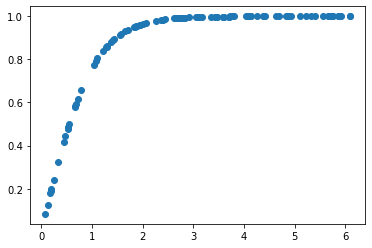

In [8]:
x = torch.rand(100) * 2 * torch.pi
y = tanh_function(x)
# plot the sine wave function
plt.scatter(x.numpy(), y.numpy())

In [9]:
def non_linear_func(x):
    
    func_1 = random.choice(funcs_list)
    exp_1 = random.randint(-5, 5)
    func_2 = random.choice(funcs_list)
    exp_2 = random.randint(-5, 5)
    
    nl = (func_1(x)**exp_1)*(func_2(x)**exp_2)
    
    output = torch.clamp(nl, 0.1, 0.9)
    
    return output

In [10]:
def fourier_func(x):
    
    amp_1 = random.randint(1, 10)
    coeff_1 = random.randint(1, 10)
    phase_1 = random.randint(1, 10)
    
    f1 = amp_1*sine_function(coeff_1*x + phase_1)
    
    amp_2 = random.randint(1, 10)
    coeff_2 = random.randint(1, 10)
    phase_2 = random.randint(1, 10)
    
    f2 = amp_2*sine_function(coeff_2*x + phase_2)
    
    amp_3 = random.randint(1, 10)
    coeff_3 = random.randint(1, 10)
    phase_3 = random.randint(1, 10)
    
    f3 = amp_3*sine_function(coeff_3*x + phase_1)
    
    output = (f1 + f2 + f3) / (amp_1 + amp_2 + amp_3)
    
    return output

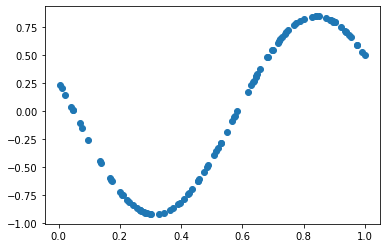

In [11]:
x = torch.rand(100)
y = fourier_func(x)
# plot the sine wave function
plt.scatter(x.numpy(), y.numpy())

In [12]:
# def generate_data_samples(n=100):
#     # here we define the number of n numbers from a Uniform distribution
#     x1 = torch.rand(n) * 2 * torch.pi
#     x2 = tanh_function(x1)
#     x3 = sine_function(x1)
#     x4 = sine_function(x1)
#     x1 = x1.view(n,1)
#     x2 = x2.view(n,1)
#     x3 = x3.view(n,1)
#     x4 = x4.view(n,1)
#     y_data = torch.ones((n,1))

#     return torch.hstack([x1, x2, x3, x4]), y_data

In [13]:
def generate_ndim_samples(n, n_dim):
    
    signals = []
    x = torch.rand(n)
    y_data = torch.ones((n,1))
    
    for dim in range(n_dim):
        
        x_dim = non_linear_func(x)
        x_dim = x_dim.view(n, 1)
        signals.append(x_dim)
    
    return torch.hstack(signals), y_data

In [14]:
def generate_ndim_fourier_samples(n, n_dim):
    
    x = torch.rand(n)
    signals = [x.view(n, 1)]
    y_data = torch.ones((n,1))
    
    for dim in range(n_dim - 1):
        
        x_dim = fourier_func(x)
        x_dim = x_dim.view(n, 1)
        signals.append(x_dim)
    
    return torch.hstack(signals), y_data

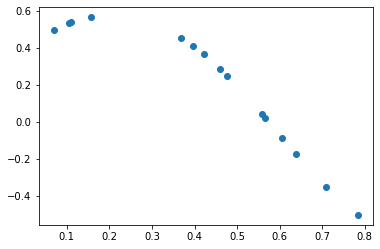

In [15]:
test_generated_data = generate_ndim_fourier_samples(15, 100)

plt.scatter(test_generated_data[0][:,0].numpy(), test_generated_data[0][:,1].numpy())

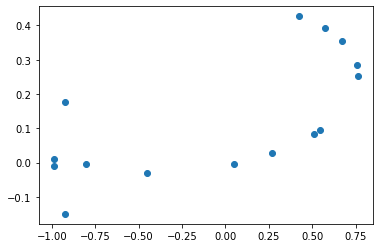

In [16]:
plt.scatter(test_generated_data[0][:,5].numpy(), test_generated_data[0][:,2].numpy())

In [17]:
test_generated_data[0].shape

torch.Size([15, 100])

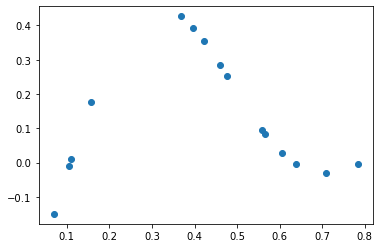

In [18]:
plt.scatter(test_generated_data[0][:,0].numpy(), test_generated_data[0][:,2].numpy())

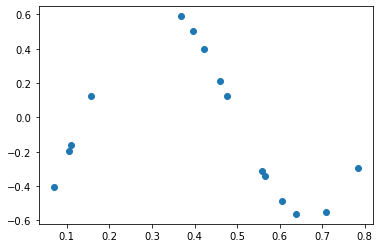

In [19]:
plt.scatter(test_generated_data[0][:,0].numpy(), test_generated_data[0][:,3].numpy())

In [20]:
# class Discriminator(nn.Module):
#     def __init__(self):
#         super(Discriminator, self).__init__()
#         self.fc1 = nn.Linear(4, 25)
#         self.fc2 = nn.Linear(25,1)

#     def forward(self,x):
#         x = self.fc1(x)
#         x = F.relu(x)
#         x = self.fc2(x)
#         x = torch.sigmoid(x)
#         return x

In [21]:
class Discriminator_ndim(nn.Module):
    def __init__(self, ndim, hidden):
        super(Discriminator_ndim, self).__init__()
        self.fc1 = nn.Linear(ndim, hidden)
        self.fc2 = nn.Linear(hidden,1)

    def forward(self,x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x

In [22]:
discriminator = Discriminator_ndim(15, 25)
# test a discriminator with a simple input - sanity check
x_data_test = torch.rand(15)
discriminator(x_data_test)

tensor([0.5301], grad_fn=<SigmoidBackward0>)

In [23]:
# def generate_dummy_fake_data(n):
#     x1 = torch.rand(n) * 2 * torch.pi
#     x2 = torch.rand(n) * 2 * torch.pi
#     x3 = torch.rand(n) * 2 * torch.pi
#     x4 = torch.rand(n) * 2 * torch.pi
#     x1 = x1.view(n,1)
#     x2 = x2.view(n,1)
#     x3 = x3.view(n,1)
#     x4 = x4.view(n,1)
#     y_fake = torch.zeros((n,1))
#     return torch.hstack((x1, x2, x3, x4)), y_fake

In [24]:
def generate_dummy_fake_ndim(n, ndim):
    
    signals = []
    y_fake = torch.zeros((n,1))
    
    for dim in range(ndim):
        
        x_dim = torch.rand(n)
        x_dim = x_dim.view(n, 1)
        signals.append(x_dim)
    
    return torch.hstack(signals), y_fake

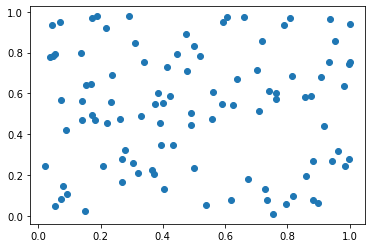

In [25]:
x_fake,y_fake = generate_dummy_fake_ndim(100, 5)
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 1].numpy())

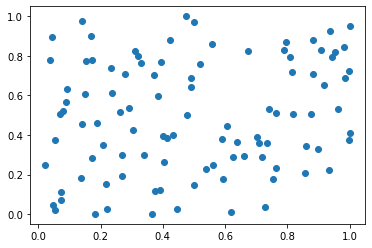

In [26]:
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 2].numpy())

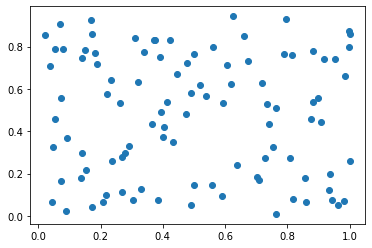

In [27]:
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 3].numpy())

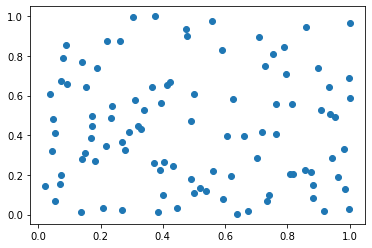

In [28]:
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 4].numpy())

In [29]:
discriminator = Discriminator_ndim(3, 5)
optimizer = torch.optim.Adam(discriminator.parameters(), lr = 0.001) 
criterion = torch.nn.BCELoss()

In [30]:
epochs = 1000
n = 100
n_dim = 15
hidden = 10

discriminator = Discriminator_ndim(n_dim, hidden)
optimizer = torch.optim.Adam(discriminator.parameters(), lr = 0.001) 
criterion = torch.nn.BCELoss()

x_data, y_data = generate_ndim_fourier_samples(n, n_dim)
x_fake, y_fake = generate_dummy_fake_ndim(n, n_dim)

x_all = torch.vstack((x_data, x_fake))
y_all = torch.vstack((y_data, y_fake))
all_loss = []
for i in range(epochs):
    y_hat = discriminator(x_all)
    loss = criterion(y_hat, y_all)
    all_loss.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

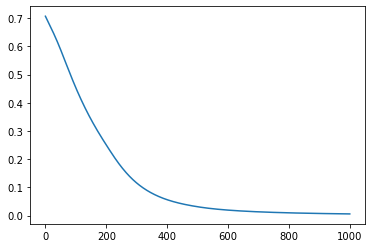

In [31]:
plt.plot(all_loss)

In [32]:
# # define a Generator Model

# class Generator(nn.Module):
#     def __init__(self):
#         super(Generator, self).__init__()

#         self.fc1 = nn.Linear(5,15)
#         self.fc2 = nn.Linear(15, 4)

#     def forward(self, x):
#         x = self.fc1(x)
#         x = F.relu(x)
#         x = self.fc2(x)
#         # note that here we are not adding any activation functions
#         # since we assume the linear output as the values can be negative as well
#         # in other words this activation function here is just an "identity function" f(x)=x
#         return x

In [33]:
class Generator_ndim(nn.Module):
    def __init__(self, n_dim, hidden):
        super(Generator_ndim, self).__init__()

        self.fc1 = nn.Linear(5, hidden)
        self.fc2 = nn.Linear(hidden, n_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        # note that here we are not adding any activation functions
        # since we assume the linear output as the values can be negative as well
        # in other words this activation function here is just an "identity function" f(x)=x
        return x

In [34]:
generator = Generator_ndim(6, 6)
test_generator = generator(torch.rand(5))
print(test_generator)

tensor([ 0.4027, -0.1482,  0.0876, -0.3468, -0.0284, -0.3830],
       grad_fn=<ViewBackward0>)


In [35]:
def generate_latent_points(n, latent_dim=5):
    # here we will assume that in the z-space 
    # or latent space we have 5 dimensional random vector 
    z = torch.rand(n*latent_dim)
    return z.view((n,latent_dim))

a = generate_latent_points(10)
print(a)

tensor([[0.4477, 0.5089, 0.8565, 0.0482, 0.2228],
        [0.2167, 0.6659, 0.9893, 0.6415, 0.4376],
        [0.9886, 0.9733, 0.0358, 0.8589, 0.5009],
        [0.2559, 0.5786, 0.7239, 0.4622, 0.3872],
        [0.9690, 0.3718, 0.0882, 0.1850, 0.3061],
        [0.8523, 0.9771, 0.2153, 0.0315, 0.5638],
        [0.7658, 0.7460, 0.3916, 0.1045, 0.7239],
        [0.2479, 0.7903, 0.6917, 0.8014, 0.1947],
        [0.9862, 0.1666, 0.4222, 0.4889, 0.6108],
        [0.0671, 0.6158, 0.7364, 0.0714, 0.9766]])


In [36]:
def generate_fake_samples(generator, n, latent_dim=5):
    z = generate_latent_points(n)
    fake_data = generator(z)
    return fake_data 

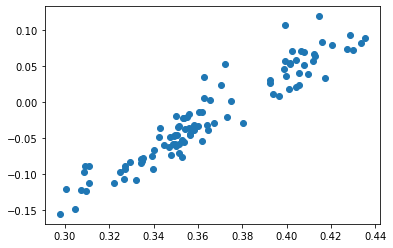

In [37]:
fake_data_test = generate_fake_samples(generator, 100)
plt.scatter(fake_data_test[:,0].detach().numpy(), fake_data_test[:,2].detach().numpy())

In [ ]:
training_steps = 100_000    
n_dim = 15
hidden_g = 35
hidden_d = 35

# Models
generator =     Generator_ndim(n_dim, hidden_g)
discriminator = Discriminator_ndim(n_dim, hidden_d)

# Optimizers
generator_optimizer     = torch.optim.Adam(generator.parameters(),     lr=0.001)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.001)

# loss
loss = nn.BCELoss()

discriminator_losses = []
generator_losses = []

N = 128

for i in tqdm(range(training_steps)):
    # zero the gradients on each iteration
    generator_optimizer.zero_grad()
#    if i%5000 ==0:
#        print(f"{i} \n")

    # Create a fake data with a generator
    fake_data = generate_fake_samples(generator, N)

    # here we define the INVERSE labels for fake data
    fake_data_label = torch.ones(N,1)

    # Generate examples of real data
    real_data, real_data_label = generate_ndim_fourier_samples(N, n_dim)
    
    # Train the generator
    # We invert the labels here and don't train the discriminator because we want the generator
    # to make things the discriminator classifies as true.
    generator_discriminator_out = discriminator(fake_data)
    generator_loss = loss(generator_discriminator_out, fake_data_label)
    generator_loss.backward()
    generator_optimizer.step()
    generator_losses.append(generator_loss.item())


    # Train the discriminator on the true/generated data
    discriminator_optimizer.zero_grad()
    true_discriminator_out = discriminator(real_data)
    true_discriminator_loss = loss(true_discriminator_out, real_data_label)

    # here a fake_data is passed with a gradient turned off
    # see our post about <a href="https://datahacker.rs/004-computational-graph-and-autograd-with-pytorch/#Automatic-differentiation-module-in-PyTorch---Autograd">AUTOGRAD</a>
    generator_discriminator_out = discriminator(fake_data.detach())
    generator_discriminator_loss = loss(generator_discriminator_out, torch.zeros(N,1))
    discriminator_loss = (true_discriminator_loss + generator_discriminator_loss) / 2
    discriminator_loss.backward()
    discriminator_optimizer.step()
    discriminator_losses.append(discriminator_loss.item())

 95%|█████████████████████████████████▎ | 95182/100000 [04:45<00:13, 358.38it/s]

In [ ]:
real_data.shape

In [ ]:
for k in range(1, n_dim):
    plt.scatter(real_data[:,0].detach().numpy(), real_data[:,k].detach().numpy())
    plt.scatter(fake_data[:,0].detach().numpy(), fake_data[:,k].detach().numpy())
    plt.title(f'dim {k} versus x')
    plt.show()

In [ ]:
plt.plot(discriminator_losses)

In [ ]:
plt.plot(generator_losses)